In [1]:
library(edgeR)
library(ggplot2)
library(ggrepel)
library(reshape2)
library(scales)
library(EnsDb.Mmusculus.v79)
library(patchwork)
library(data.table)

Loading required package: limma

Loading required package: ensembldb

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, setdiff, sort, table,
    tapply, union, unique, unsplit, which.max, which.min


Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    I, expand.grid, unname


Loading required pac

In [2]:
library(ComplexHeatmap)
library(grid)
#library(clusterProfiler)
library(circlize)
library(org.Mm.eg.db)
library(stringr)

Loading required package: grid

ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.13
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

Thi

## Preparing data; get differentially expressed genes

In [3]:
# read in raw counts
setwd("~/Dropbox (MIT)/MVH_Code/brq/code/")
count_data = read.table("../data/210405_633_brq_e2_raw_counts.tsv", header=TRUE, row.names=1)
count_data = count_data[,6:dim(count_data)[2]]
print(dim(count_data))
# head(df)

[1] 55401    40


In [4]:
# change colnames and rownames

colnames(count_data) = gsub("results.star.", "", gsub("_Aligned.sortedByCoord.out.bam", "", colnames(count_data)))

rownames(count_data) = as.character(sapply(rownames(count_data), function(x) strsplit(x, '[.]')[[1]][1]))
annotations_orgDb <- AnnotationDbi::select(EnsDb.Mmusculus.v79, # database
                                     keys = rownames(count_data) ,  # data to use for retrieval
                                     columns = c("SYMBOL"), # information to retreive for given data
                                     keytype = "GENEID") # type of data given in 'keys' argument
annotations_orgDb = annotations_orgDb[!duplicated(annotations_orgDb$SYMBOL),]

count_data = count_data[annotations_orgDb$GENEID,]  # you lose a few genes here but not many
rownames(count_data) = annotations_orgDb$SYMBOL
                                   
head(count_data)

,BRQ_4h_rep2,BRQ_24h_rep2,BRQ_8h_rep2,BRQ_96h_rep1,BRQ_4h_rep1,BRQ_12h_rep1,BRQ_48h_rep1,BRQ_2h_rep2,BRQ_0h_rep1,BRQ_8h_rep1,⋯,633_E2w_0h_rep2,633_E2w_4h_rep2,633_E2w_8h_rep2,633_E2w_12h_rep2,633_E2w_24h_rep2,633_E2w_36h_rep2,633_E2w_48h_rep2,633_E2w_72h_rep2,633_E2w_96h_rep2,633_E2w_120h_rep2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RP23-271O17.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm26206,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Xkr4,0,0,0,2,0,12,0,0,0,0,⋯,0,6,12,10,2,2,0,0,0,0
RP23-317L18.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP23-317L18.4,0,0,0,0,0,0,0,0,14,0,⋯,2,2,2,0,0,0,0,0,1,0
RP23-317L18.3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [5]:
# reorder
count_data = count_data[,c("BRQ_0h_rep1", "BRQ_0h_rep2", "BRQ_2h_rep1", "BRQ_2h_rep2", "BRQ_4h_rep1", "BRQ_4h_rep2", 
                      "BRQ_6h_rep1", "BRQ_6h_rep2", "BRQ_8h_rep1", "BRQ_8h_rep2", "BRQ_12h_rep1", "BRQ_12h_rep2",
                      "BRQ_24h_rep1", "BRQ_24h_rep2", "BRQ_48h_rep1", "BRQ_48h_rep2", "BRQ_72h_rep1", "BRQ_72h_rep2",
                       "BRQ_96h_rep1", "BRQ_96h_rep2",
                       "633_E2w_0h_rep1", "633_E2w_0h_rep2", "633_E2w_4h_rep1", "633_E2w_4h_rep2", "633_E2w_8h_rep1", "633_E2w_8h_rep2",
                       "633_E2w_12h_rep1", "633_E2w_12h_rep2", "633_E2w_24h_rep1", "633_E2w_24h_rep2", "633_E2w_36h_rep1", "633_E2w_36h_rep2",
                       "633_E2w_48h_rep1", "633_E2w_48h_rep2", "633_E2w_72h_rep1", "633_E2w_72h_rep2", "633_E2w_96h_rep1", "633_E2w_96h_rep2",
                       "633_E2w_120h_rep1", "633_E2w_120h_rep2")]

# # reorder BRQ_2h_rep2 with BRQ_4h_rep1 since those were not annotated correctly 
# swapped_cols = count_data[,c(5,4)]
# colnames(swapped_cols) = c("BRQ_2h_rep2", "BRQ_4h_rep1")
# count_data = cbind(count_data[,1:3], swapped_cols, count_data[,6:40])
head(count_data)

,BRQ_0h_rep1,BRQ_0h_rep2,BRQ_2h_rep1,BRQ_2h_rep2,BRQ_4h_rep1,BRQ_4h_rep2,BRQ_6h_rep1,BRQ_6h_rep2,BRQ_8h_rep1,BRQ_8h_rep2,⋯,633_E2w_36h_rep1,633_E2w_36h_rep2,633_E2w_48h_rep1,633_E2w_48h_rep2,633_E2w_72h_rep1,633_E2w_72h_rep2,633_E2w_96h_rep1,633_E2w_96h_rep2,633_E2w_120h_rep1,633_E2w_120h_rep2
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RP23-271O17.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Gm26206,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Xkr4,0,0,0,0,0,0,0,0,0,0,⋯,0,2,0,0,0,0,0,0,0,0
RP23-317L18.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
RP23-317L18.4,14,0,0,0,0,0,8,0,0,0,⋯,0,0,0,0,4,0,0,1,0,0
RP23-317L18.3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [6]:
# limma-voom normalization

d0 <- DGEList(count_data)
d0 <- calcNormFactors(d0)
cutoff <- 3
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop,] 
dim(d) # number of genes left

[1] 12983    40

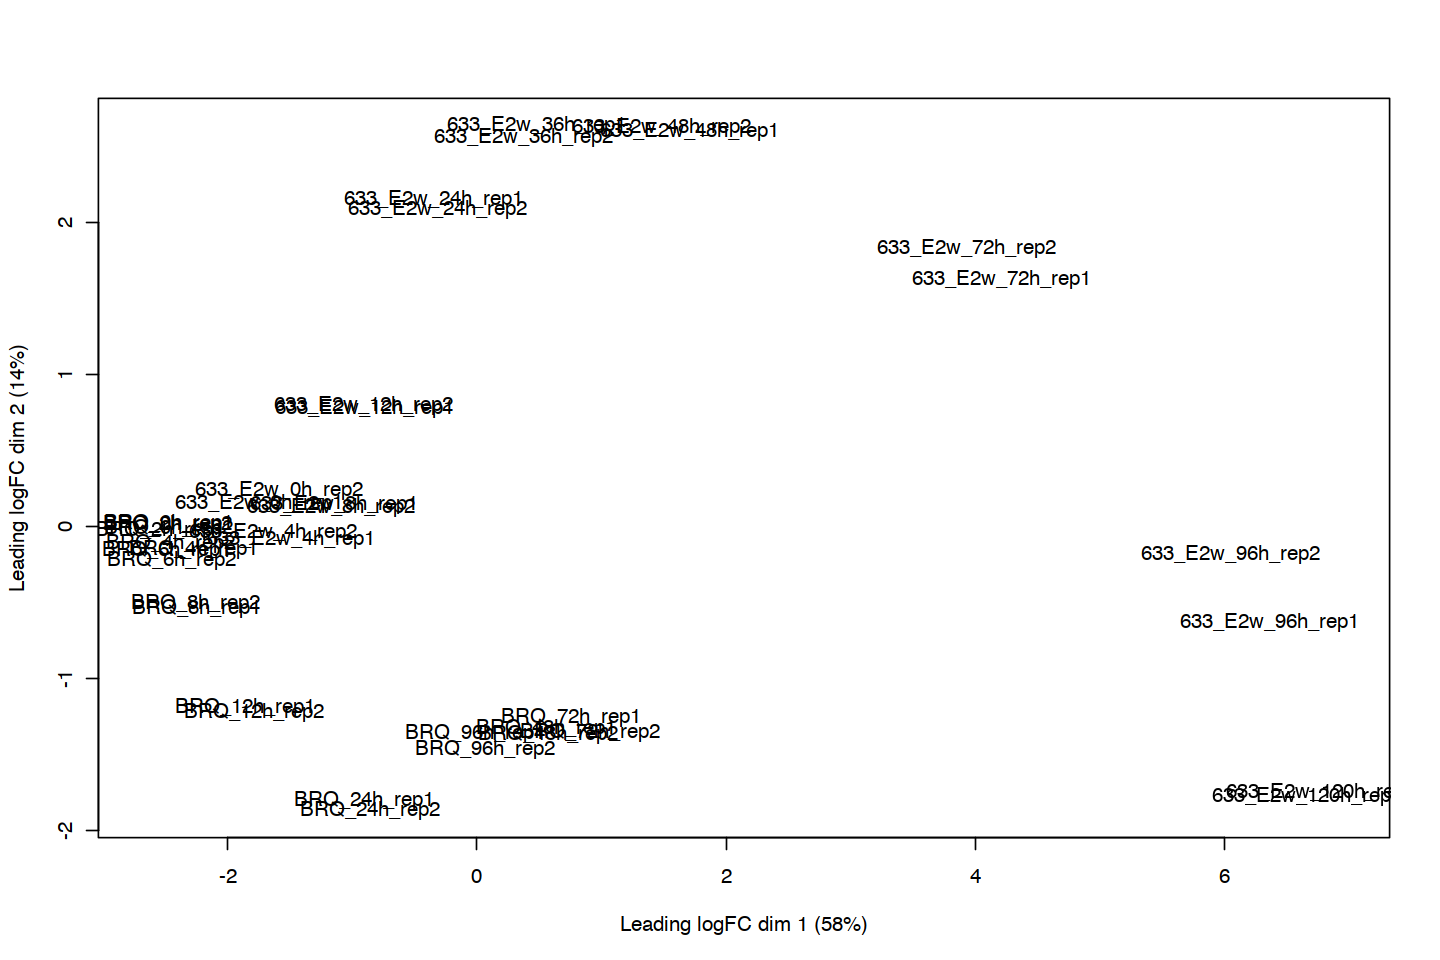

In [7]:
options(repr.plot.width=12, repr.plot.height=8)
#pdf("mdsplot.pdf", width=50, height=50)
plotMDS(d)
#dev.off()

In [9]:
# get counts per million and write table 
cpm_vals = cpm(d, log=TRUE, prior.count=3)
write.csv(cpm_vals, file="../data/210421_633_brq_e2w_rnaseq_log_cpm.csv", quote=F)
head(cpm_vals)

,BRQ_0h_rep1,BRQ_0h_rep2,BRQ_2h_rep1,BRQ_2h_rep2,BRQ_4h_rep1,BRQ_4h_rep2,BRQ_6h_rep1,BRQ_6h_rep2,BRQ_8h_rep1,BRQ_8h_rep2,⋯,633_E2w_36h_rep1,633_E2w_36h_rep2,633_E2w_48h_rep1,633_E2w_48h_rep2,633_E2w_72h_rep1,633_E2w_72h_rep2,633_E2w_96h_rep1,633_E2w_96h_rep2,633_E2w_120h_rep1,633_E2w_120h_rep2
Mrpl15,6.713146,6.520037,6.536072,6.670286,6.486532,6.634415,6.221050,6.150138,5.894309,5.929673,⋯,6.535348,6.465442,6.148400,6.160432,5.400269,5.721165,4.973701,4.724085,4.942570,5.156600
Lypla1,6.334280,6.275615,6.407374,6.577926,6.349148,6.501551,6.324821,6.331994,6.318540,6.338262,⋯,7.021458,6.910749,6.890058,7.122950,7.023488,7.136403,7.031072,6.877112,6.985250,6.889528
RP24-426M1.3,4.997911,5.021264,5.153718,5.270519,5.121053,5.243147,5.134315,5.155950,5.029567,4.993949,⋯,5.106281,5.080913,4.937943,5.121040,4.873773,4.964717,5.046954,4.755924,4.936216,4.830166
Tcea1,7.292051,7.235587,7.329929,7.319898,7.364407,7.327297,7.215142,7.146185,6.927842,7.079222,⋯,7.426865,7.373496,7.059390,7.339118,6.849130,6.939185,7.013781,6.646117,6.669542,6.705267
Gm6104,3.963615,3.964461,3.994192,4.140236,4.083038,4.004925,4.238743,4.222944,3.780851,4.220393,⋯,3.469746,3.487318,3.227843,3.353461,2.819287,2.888675,1.829393,1.943217,-1.257469,-1.406029
Atp6v1h,6.296935,6.322661,6.197034,6.144644,6.179970,6.131141,6.225907,6.075413,6.035190,6.017780,⋯,6.733229,6.740717,6.697961,6.794731,6.772076,6.902699,7.130321,6.928719,7.298243,7.413832


In [25]:
# average each replicate
cpm_even = cpm_vals[,seq(1,20)*2]
cpm_odd = cpm_vals[,seq(1,20)*2-1]
cpm_avg = (cpm_even + cpm_odd)/2
head(cpm_avg)

,BRQ_0h_rep2,BRQ_2h_rep2,BRQ_4h_rep2,BRQ_6h_rep2,BRQ_8h_rep2,BRQ_12h_rep2,BRQ_24h_rep2,BRQ_48h_rep2,BRQ_72h_rep2,BRQ_96h_rep2,633_E2w_0h_rep2,633_E2w_4h_rep2,633_E2w_8h_rep2,633_E2w_12h_rep2,633_E2w_24h_rep2,633_E2w_36h_rep2,633_E2w_48h_rep2,633_E2w_72h_rep2,633_E2w_96h_rep2,633_E2w_120h_rep2
Mrpl15,6.616592,6.603179,6.560473,6.185594,5.911991,5.621082,5.484744,5.348352,5.738977,5.907784,6.564825,6.330050,6.229390,6.380139,6.651166,6.500395,6.154416,5.560717,4.848893,5.049585
Lypla1,6.304947,6.492650,6.425350,6.328408,6.328401,6.180385,5.711289,5.510399,5.559903,5.890970,6.977318,6.807691,6.841313,6.837314,7.050957,6.966103,7.006504,7.079945,6.954092,6.937389
RP24-426M1.3,5.009588,5.212119,5.182100,5.145132,5.011758,4.781026,4.294160,4.237933,4.479272,4.689618,5.208419,5.071363,4.985124,5.113831,5.184603,5.093597,5.029491,4.919245,4.901439,4.883191
Tcea1,7.263819,7.324913,7.345852,7.180664,7.003532,6.731628,6.391927,6.440932,6.716412,6.869404,7.609813,7.452329,7.250443,7.333409,7.570591,7.400180,7.199254,6.894157,6.829949,6.687404
Gm6104,3.964038,4.067214,4.043981,4.230843,4.000622,3.355861,2.962283,2.528334,2.233063,2.757197,4.384178,4.246851,3.920890,3.912478,3.767636,3.478532,3.290652,2.853981,1.886305,-1.331749
Atp6v1h,6.309798,6.170839,6.155556,6.150660,6.026485,5.991880,5.737471,5.788361,6.128154,6.277434,6.521981,6.281078,6.391440,6.610792,6.848353,6.736973,6.746346,6.837388,7.029520,7.356038


In [11]:
# get LFC
lfc = cpm_avg 
lfc[,1:10] = lfc[,1:10] - cpm_avg[,1]
lfc[,11:20] = lfc[,11:20] - cpm_avg[,11]
head(lfc)

,BRQ_0h_rep2,BRQ_2h_rep2,BRQ_4h_rep2,BRQ_6h_rep2,BRQ_8h_rep2,BRQ_12h_rep2,BRQ_24h_rep2,BRQ_48h_rep2,BRQ_72h_rep2,BRQ_96h_rep2,633_E2w_0h_rep2,633_E2w_4h_rep2,633_E2w_8h_rep2,633_E2w_12h_rep2,633_E2w_24h_rep2,633_E2w_36h_rep2,633_E2w_48h_rep2,633_E2w_72h_rep2,633_E2w_96h_rep2,633_E2w_120h_rep2
Mrpl15,0,-0.01341224,-0.05611814,-0.43099799,-0.704600870,-0.9955099,-1.1318480,-1.2682394,-0.8776146,-0.70880737,0,-0.2347742,-0.3354349,-0.18468559,0.08634160,-0.06442983,-0.41040898,-1.0041075,-1.71593153,-1.51523964
Lypla1,0,0.18770242,0.12040219,0.02346032,0.023453495,-0.1245629,-0.5936585,-0.7945488,-0.7450447,-0.41397765,0,-0.1696271,-0.1360056,-0.14000395,0.07363891,-0.01121515,0.02918566,0.1026270,-0.02322627,-0.03992953
RP24-426M1.3,0,0.20253101,0.17251205,0.13554437,0.002170402,-0.2285619,-0.7154277,-0.7716551,-0.5303158,-0.31996952,0,-0.1370558,-0.2232953,-0.09458822,-0.02381638,-0.11482208,-0.17892788,-0.2891742,-0.30698019,-0.32522844
Tcea1,0,0.06109410,0.08203262,-0.08315566,-0.260286922,-0.5321909,-0.8718922,-0.8228871,-0.5474073,-0.39441481,0,-0.1574838,-0.3593695,-0.27640411,-0.03922160,-0.20963253,-0.41055855,-0.7156555,-0.77986378,-0.92240832
Gm6104,0,0.10317631,0.07994367,0.26680566,0.036584134,-0.6081770,-1.0017549,-1.4357040,-1.7309752,-1.20684112,0,-0.1373264,-0.4632873,-0.47169986,-0.61654134,-0.90564581,-1.09352573,-1.5301966,-2.49787238,-5.71592635
Atp6v1h,0,-0.13895941,-0.15424218,-0.15913766,-0.283313028,-0.3179183,-0.5723272,-0.5214369,-0.1816442,-0.03236369,0,-0.2409027,-0.1305405,0.08881129,0.32637256,0.21499208,0.22436544,0.3154068,0.50753884,0.83405676


In [7]:
# get DEGs
conds = as.character(sapply(colnames(count_data), function(x) substr(x, 1, nchar(x)-5)))

mm <- model.matrix(~0 + conds)
y <- voom(d, mm, plot = F)
fit <- lmFit(y, mm)
head(coef(fit))

,conds633_E2w_0h,conds633_E2w_120h,conds633_E2w_12h,conds633_E2w_24h,conds633_E2w_36h,conds633_E2w_48h,conds633_E2w_4h,conds633_E2w_72h,conds633_E2w_8h,conds633_E2w_96h,condsBRQ_0h,condsBRQ_12h,condsBRQ_24h,condsBRQ_2h,condsBRQ_48h,condsBRQ_4h,condsBRQ_6h,condsBRQ_72h,condsBRQ_8h,condsBRQ_96h
Mrpl15,6.566449,5.042568,6.378438,6.651221,6.499780,6.153816,6.329467,5.560264,6.228578,4.846882,6.614200,5.620159,5.482484,6.604800,5.354624,6.564154,6.186844,5.738999,5.910795,5.898922
Lypla1,6.979090,6.938078,6.837910,7.050424,6.965653,7.006567,6.807227,7.079676,6.840919,6.953619,6.303686,6.179852,5.709599,6.494958,5.514458,6.429473,6.327725,5.560758,6.327649,5.885250
RP24-426M1.3,5.209338,4.884675,5.113289,5.182482,5.092163,5.029556,5.069933,4.917935,4.984023,4.899395,5.008731,4.779463,4.294927,5.213955,4.245505,5.186832,5.143187,4.479856,5.011091,4.688824
Tcea1,7.609908,6.686529,7.333432,7.570291,7.399894,7.199250,7.452053,6.893836,7.250106,6.829273,7.263174,6.731217,6.391688,7.324566,6.444069,7.344980,7.181371,6.716355,7.002088,6.869172
Gm6104,4.388347,-1.438999,3.911232,3.765254,3.474476,3.287465,4.244282,2.847935,3.917651,1.874885,3.961315,3.351708,2.950544,4.069623,2.525368,4.036498,4.229364,2.233219,3.987485,2.770064
Atp6v1h,6.522975,7.354930,6.610984,6.847784,6.736549,6.746168,6.280430,6.837093,6.390761,7.029047,6.309574,5.991335,5.739537,6.169297,5.792020,6.153294,6.153995,6.128127,6.026054,6.279889


In [8]:
# function to process results

process_res = function(res, fit) {
    tmp <- contrasts.fit(fit, res)
    tmp <- eBayes(tmp)
    res <- topTable(tmp, sort.by = "P", n = Inf)
    return(res)
}

In [9]:
# get list of differentially expressed genes for each timepoint 
e2w_degs = list()
for (tp in c(4,8,12,24,36,48,72,96)) {
    formula = paste("conds633_E2w_", toString(tp), "h - conds633_E2w_0h", sep='')
    e2w_degs[[toString(tp)]] = process_res(makeContrasts(formula, levels = colnames(coef(fit))), fit)
}

brq_degs = list()
for (tp in c(2,4,6,8,12,24,48,72,96)) {
    formula = paste("condsBRQ_", toString(tp), "h - condsBRQ_0h", sep='')
    brq_degs[[toString(tp)]] = process_res(makeContrasts(formula, levels = colnames(coef(fit))), fit)
}

## PCA plot

In [14]:
# make PCA plot
lfc_red = lfc[,-20]
p = prcomp(lfc_red)
rot_matrix = as.data.frame(p$rotation[,1:2])
rot_matrix$PC2 = -rot_matrix$PC2
rot_matrix$tp = sapply(gsub("BRQ_", "", gsub("633_E2w_", "", gsub("rep", "", rownames(rot_matrix)))),
                       function(x) strsplit(x, '_')[[1]][1])

rot_matrix$tx = sapply(gsub("633_E2w", "-E2", rownames(rot_matrix)),
                       function(x) strsplit(x, '_')[[1]][1])
                       
rot_matrix$tx = factor(rot_matrix$tx, levels=c("BRQ","-E2"))
head(rot_matrix)

,PC1,PC2,tp,tx
,<dbl>,<dbl>,<chr>,<fct>
BRQ_0h_rep2,0.000000000,0.00000000,0h,BRQ
BRQ_2h_rep2,-0.003819172,-0.05305720,2h,BRQ
BRQ_4h_rep2,-0.012650048,-0.05926372,4h,BRQ
BRQ_6h_rep2,-0.030418651,-0.13525372,6h,BRQ
BRQ_8h_rep2,-0.060984515,-0.21033322,8h,BRQ
BRQ_12h_rep2,-0.117992017,-0.33668590,12h,BRQ


In [15]:
# get explained variances 
exp_variance = p$sdev^2/sum(p$sdev^2)
exp_variance

[1] 6.584369e-01 1.523051e-01 6.624842e-02 4.692433e-02 2.036362e-02
 [6] 1.463219e-02 7.838283e-03 7.274532e-03 6.352939e-03 4.524962e-03
[11] 4.145284e-03 2.640243e-03 2.507069e-03 2.258490e-03 1.975556e-03
[16] 9.738589e-04 5.983026e-04 7.604611e-35 0.000000e+00

In [16]:
rot_matrix

,PC1,PC2,tp,tx
,<dbl>,<dbl>,<chr>,<fct>
BRQ_0h_rep2,0.000000e+00,0.000000e+00,0h,BRQ
BRQ_2h_rep2,-3.819172e-03,-5.305720e-02,2h,BRQ
BRQ_4h_rep2,-1.265005e-02,-5.926372e-02,4h,BRQ
BRQ_6h_rep2,-3.041865e-02,-1.352537e-01,6h,BRQ
BRQ_8h_rep2,-6.098452e-02,-2.103332e-01,8h,BRQ
BRQ_12h_rep2,-1.179920e-01,-3.366859e-01,12h,BRQ
BRQ_24h_rep2,-2.103838e-01,-4.502194e-01,24h,BRQ
BRQ_48h_rep2,-2.992268e-01,-3.665556e-01,48h,BRQ
BRQ_72h_rep2,-2.857982e-01,-2.941190e-01,72h,BRQ


Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."


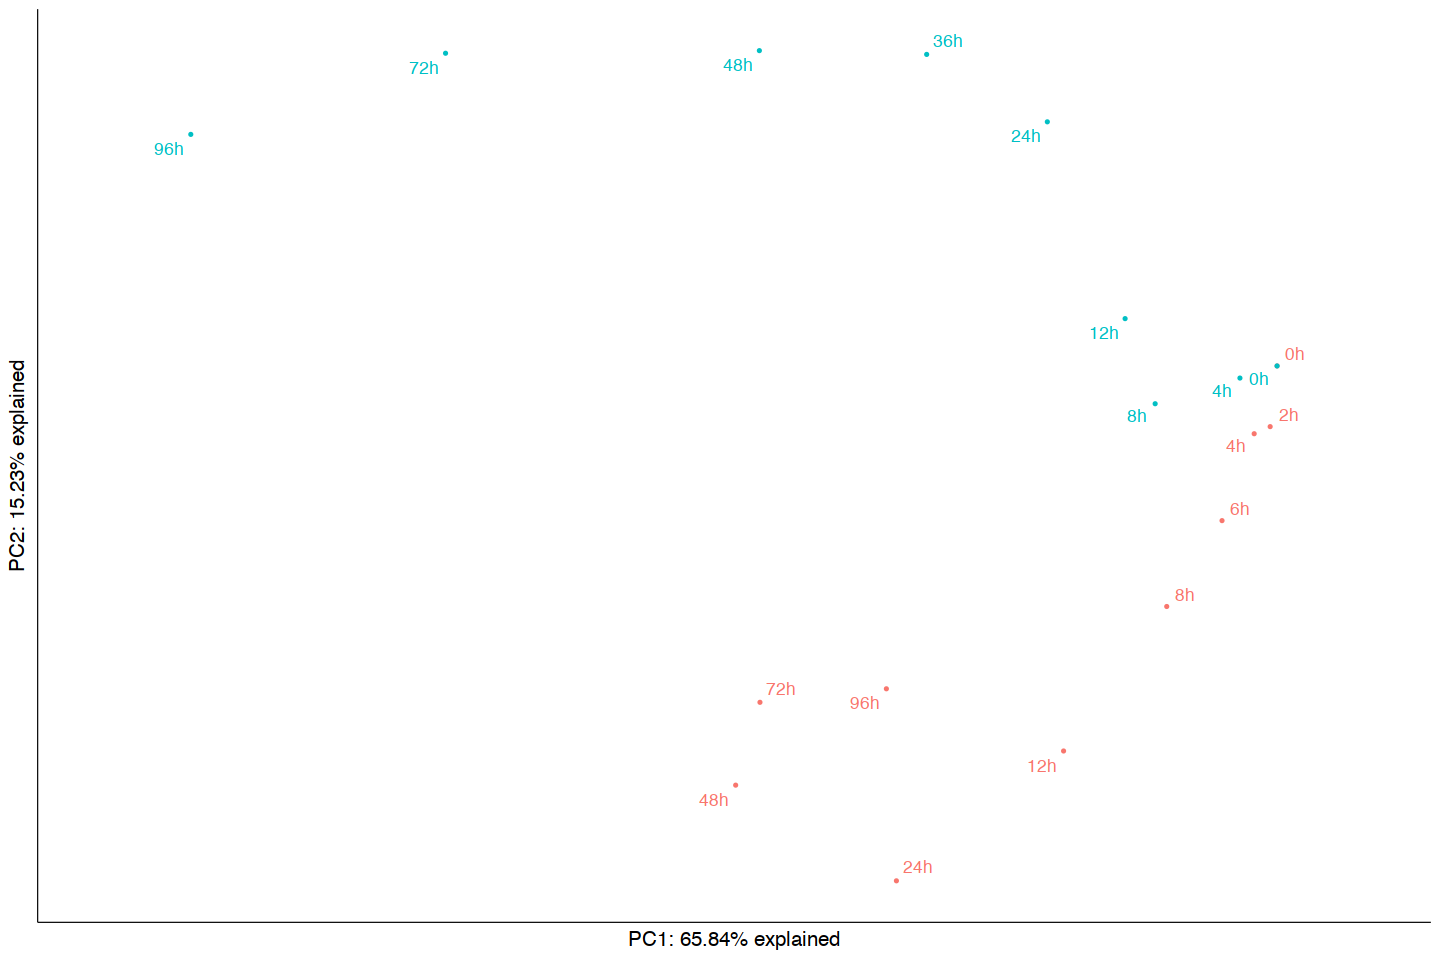

In [82]:
# Draw PCA plot

g = ggplot(data=rot_matrix, aes(x=PC1, y=PC2)) + geom_point(aes(color=tx), size=0.4) + 
labs(x=paste("PC1: ", format(round(exp_variance[1]*100, 2), nsmall = 2), "% explained", sep='')) +
labs(y=paste("PC2: ", format(round(exp_variance[2]*100, 2), nsmall = 2), "% explained", sep='')) +
geom_text_repel(aes(label=tp, color=tx), size=10*5/14, force = 0.06,  
                seed=42) + 
theme_bw() + xlim(c(-0.65, 0.05)) +
guides(color=F) +
theme(panel.border = element_blank(), 
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black", size=0.25),
      axis.ticks.x=element_blank(),
      axis.text.x=element_blank(),
      axis.ticks.y=element_blank(),
      axis.text.y=element_blank(),
      text = element_text(size = 12))
g
ggsave("../figures/erhoxa9_pca_v2.pdf", width=4, height=3, units="in")


## Upreg and downreg genes

In [10]:
# get genes that are up and downregulated in all timepoints in BRQ
brq_up = c()
brq_down = c()

for (tp in names(brq_degs)) {
    res = brq_degs[[tp]]
    brq_up = union(brq_up, rownames(res[res$logFC > 1 & res$adj.P.Val < 0.05,]))
    brq_down = union(brq_down, rownames(res[res$logFC < -1 & res$adj.P.Val < 0.05,]))
}

# get genes that are up and downregulated in all timepoints in -E2 
e2w_up = c()
e2w_down = c()

for (tp in names(e2w_degs)) {
    res = e2w_degs[[tp]]
    e2w_up = union(e2w_up, rownames(res[res$logFC > 1 & res$adj.P.Val < 0.05,]))
    e2w_down = union(e2w_down, rownames(res[res$logFC < -1 & res$adj.P.Val < 0.05,]))
}

length(brq_up)
length(brq_down)
length(e2w_up)
length(e2w_down)

[1] 2915

[1] 2716

[1] 3561

[1] 3511

In [11]:
# Processing genes that are differentially upreg and downreg in BRQ vs -E2 

brq_up = subset(brq_degs[["48"]], logFC > 1 & adj.P.Val < 0.05)
dim(brq_up)

e2w_up = subset(e2w_degs[["48"]], logFC > 1 & adj.P.Val < 0.05)
dim(e2w_up)

e2w_up96 = subset(e2w_degs[["96"]], logFC > 1 & adj.P.Val < 0.05)
dim(e2w_up96)

length(intersect(rownames(brq_up), rownames(e2w_up)))  # up in both

length(setdiff(rownames(brq_up), rownames(e2w_up)))  # up only in brq
length(setdiff(rownames(e2w_up), rownames(brq_up)))  # up only in e2w

length(setdiff(rownames(brq_up), rownames(e2w_up96)))  # up only in brq48 vs. e96



[1] 1926    6

[1] 1327    6

[1] 3182    6

[1] 930

[1] 996

[1] 397

[1] 497

In [21]:
dim(subset(e2w_degs[["96"]], logFC > 1 & adj.P.Val < 0.05))

[1] 3182    6

In [17]:
setdiff(rownames(brq_up), rownames(e2w_up96))[401:496]

[1] "Foxo6"         "Spred3"        "Cml1"          "Gm10419"      
 [5] "Gm996"         "2810002D19Rik" "Tbc1d30"       "BC022960"     
 [9] "Parvb"         "mt-Ta"         "Csgalnact1"    "Fbxo44"       
[13] "Iglon5"        "Gimap8"        "Zfp174"        "Slc22a8"      
[17] "RP24-539A2.1"  "Trpv4"         "Sorbs3"        "mt-Tc"        
[21] "4930503B20Rik" "3110083C13Rik" "Rac3"          "Pex11g"       
[25] "Fam83h"        "4921507P07Rik" "Nes"           "Six4"         
[29] "Mrgpra9"       "Ptrf"          "Hs3st6"        "Rsph9"        
[33] "Gm17090"       "Abhd6"         "Capn3"         "Tmprss7"      
[37] "Ccdc63"        "Ttc6"          "9530056K15Rik" "Hexim1"       
[41] "Gm20544"       "Gnat2"         "Ccpg1os"       "Gm26512"      
[45] "RP23-211O3.4"  "Gab1"          "Cdr2l"         "Lace1"        
[49] "mt-Ty"         "Gm16277"       "Cd59a"         "Epor"         
[53] "She"           "Mypop"         "Gchfr"         "Tgfbr3l"      
[57] "Poln"          "Zfp382"        "RP24-175I14.3" "Eva1b"        
[61] "Dennd2c"       "Tspan9"        "Espn"          "Gm16271"      
[65] "Dnah1"         "Tnxb"          "Spocd1"        "Angel1"       
[69] "Gm28047"       "Gm16185"       "Zscan30"       "B4galnt4"     
[73] "H2-Ab1"        "Gm12428"       "Gm13205"       "Gm9726"       
[77] "C030037D09Rik" "Gm15581"       "Reep1"         "Col7a1"       
[81] "Naaladl1"      "Fam221a"       "Mrc1"          "Ccdc114"      
[85] "Nradd"         "Gm10825"       "4930568A12Rik" "Gm14085"      
[89] "Frmpd1"        "Sapcd1"        "4930556M19Rik" "Gimap7"       
[93] "Spef2"         "Col23a1"       "Myct1"         "Olfml3"

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



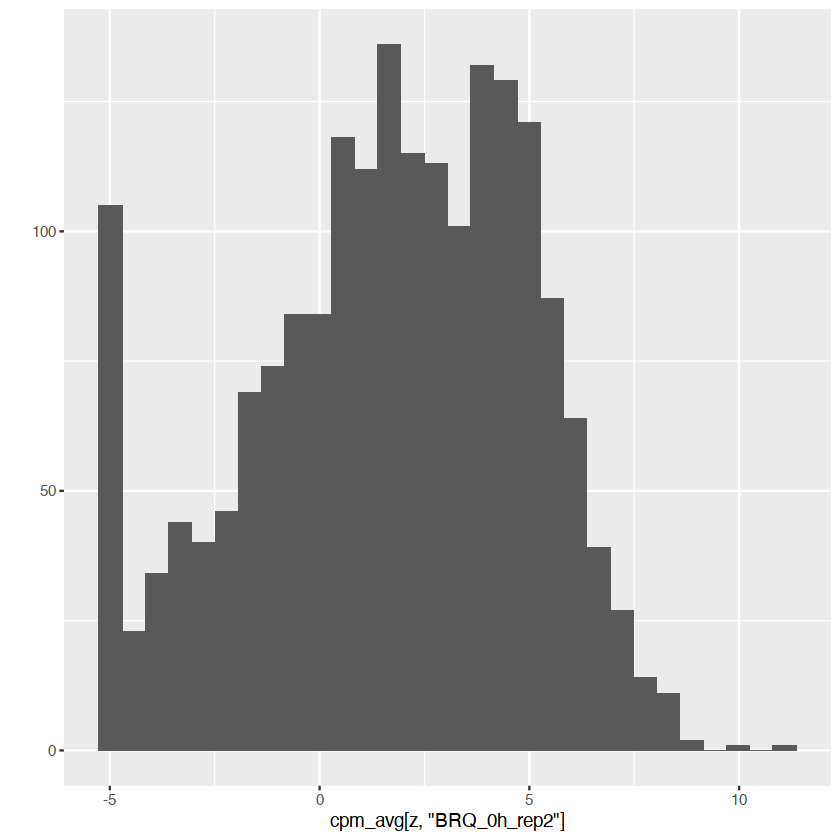

In [41]:
# which are not expressed at baseline
z = rownames(subset(brq_degs[["48"]], logFC > 1 & adj.P.Val < 0.05))
qplot(cpm_avg[z, "BRQ_0h_rep2"])

In [52]:
cpm_avg["Cntnap3",]

ERROR: Error in cpm_avg["Cntnap3", ]: subscript out of bounds


In [46]:
rownames(subset(as.data.frame(cpm_avg[z,]), BRQ_0h_rep2 > 5))

[1] "Alas1"         "Stom"          "Thbs1"         "Pcyt1a"       
  [5] "Rab27a"        "Itgb2"         "Myo1f"         "Cd33"         
  [9] "Cd93"          "Idh1"          "Cpa3"          "Gda"          
 [13] "Tcn2"          "Fcgr3"         "Itm2b"         "Rin3"         
 [17] "Litaf"         "Unc93b1"       "Rnf130"        "Adam17"       
 [21] "Papss2"        "Fam117a"       "Cxcr4"         "Cerk"         
 [25] "Tnfrsf1b"      "Micu1"         "Arel1"         "Man2b1"       
 [29] "Sorl1"         "Itm2c"         "Edem1"         "Tyrobp"       
 [33] "Csf2rb"        "Glipr1"        "Nfam1"         "Tex2"         
 [37] "Prkcd"         "Sla"           "Tec"           "Atrn"         
 [41] "Slc8b1"        "Msrb1"         "Tpp1"          "Sun2"         
 [45] "Pim1"          "Ncf1"          "Pdcd4"         "Grn"          
 [49] "Rgs2"          "Gsr"           "Plin2"         "Rab31"        
 [53] "Arhgef6"       "Spi1"          "Soat1"         "Gria3"        
 [57] "B3gnt8"        "Arsb"          "Neu1"          "Fes"          
 [61] "Ncoa4"         "Tgfbi"         "Csf2ra"        "Plod1"        
 [65] "Spidr"         "Gsn"           "Mxd4"          "Fcgr2b"       
 [69] "Tbc1d9b"       "Oxr1"          "Pygl"          "Psap"         
 [73] "Emilin2"       "Anxa1"         "Stat3"         "Wipf1"        
 [77] "Megf9"         "Sema4a"        "Nfe2"          "Pafah2"       
 [81] "Ehd4"          "Fam107b"       "Cebpa"         "Ank"          
 [85] "Ezr"           "Mtmr6"         "Cotl1"         "Fyb"          
 [89] "Sgpl1"         "Alox5ap"       "Dstn"          "Plcb2"        
 [93] "Tmem229b"      "Napsa"         "Rassf4"        "Plxnd1"       
 [97] "Tmsb4x"        "Chd3"          "Ncf2"          "Adssl1"       
[101] "Bckdha"        "Crlf3"         "Flot1"         "Cast"         
[105] "Arhgap9"       "Btg1"          "Klf13"         "Rbl2"         
[109] "Arid3a"        "Serinc3"       "St8sia4"       "Sp110"        
[113] "Tnfrsf1a"      "Aff1"          "Atg12"         "Pecam1"       
[117] "Lat2"          "Cyth4"         "Bin3"          "Arrb2"        
[121] "Csgalnact2"    "Acot1"         "Arhgap18"      "F13a1"        
[125] "Pik3ap1"       "B3gnt2"        "Sirpa"         "Aldh2"        
[129] "Ctsd"          "Sh3kbp1"       "Tmx4"          "Aplp2"        
[133] "Slc44a2"       "Pik3cb"        "Atp2a3"        "Slc12a6"      
[137] "Cdc25b"        "Ndrg1"         "Abca7"         "Heatr5a"      
[141] "Tm6sf1"        "Smim14"        "Afap1"         "Sft2d2"       
[145] "Ctsb"          "Gm28048"       "Hexa"          "Cyth1"        
[149] "Itgb5"         "Il18rap"       "Zeb2"          "Dennd5a"      
[153] "Tuba8"         "Plekhb2"       "Ehbp1l1"       "Ogfrl1"       
[157] "Rgs18"         "Rnf144a"       "Prex1"         "Nebl"         
[161] "Tgfbr2"        "Cited2"        "Selplg"        "Lta4h"        
[165] "Pcyox1"        "Rassf5"        "Wdfy2"         "Hmha1"        
[169] "Ptk2b"         "H2-T22"        "Lamp2"         "Tifab"        
[173] "Ift140"        "Ankrd28"       "Mapk3"         "Wbp2"         
[177] "Rab44"         "Chst12"        "Pde6d"         "Dgkd"         
[181] "Gpc1"          "Spn"           "Svip"          "Capn5"        
[185] "Prdx5"         "Lamp1"         "Skap2"         "Mtmr3"        
[189] "Zfyve27"       "Bin2"          "Vcl"           "Plekho2"      
[193] "Lima1"         "Tor4a"         "Samhd1"        "Nin"          
[197] "Atp13a2"       "Chek2"         "Serinc5"       "Rnf166"       
[201] "mt-Rnr2"       "Jak2"          "Atp6v0b"       "Klhl24"       
[205] "Scp2"          "mt-Rnr1"       "Kif1b"         "Gm8995"       
[209] "Atp11a"        "Nusap1"        "Rilpl2"        "Man1c1"       
[213] "Gns"           "Stat5b"        "Prkar2b"       "Tpd52"        
[217] "Cd180"         "Dock8"         "Iqgap3"        "Adcy7"        
[221] "Dok3"          "Wrn"           "Cep350"        "Rgs12"        
[225] "Arhgap6"       "Sidt2"         "Hipk1"         "Triobp"       
[229] "Anxa5

In [18]:
# Processing genes that are differentially upreg and downreg in BRQ vs -E2 

brq_down = subset(brq_degs[["48"]], logFC < -1 & adj.P.Val < 0.05)
dim(brq_down)

e2w_down = subset(e2w_degs[["48"]], logFC < -1 & adj.P.Val < 0.05)
dim(e2w_down)

length(intersect(rownames(brq_down), rownames(e2w_down)))  # down in both

intersect(rownames(brq_down), rownames(e2w_down))
setdiff(rownames(brq_down), rownames(e2w_down))  # down only in brq


[1] 1568    6

[1] 951   6

[1] 217

[1] "Fubp1"         "Myh7b"         "Hsph1"         "Ipo5"         
  [5] "Odc1"          "Mybbp1a"       "Spry4"         "Slc22a3"      
  [9] "Utp20"         "Slc39a10"      "Bzw2"          "Rrp12"        
 [13] "Gpr12"         "Pno1"          "Slc7a5"        "Bcat1"        
 [17] "Mtap"          "Endod1"        "Hmgb3"         "Rangrf"       
 [21] "Hmga2"         "Smyd5"         "Mcpt8"         "Lamc1"        
 [25] "Slc25a35"      "Wars"          "2610318N02Rik" "Etv5"         
 [29] "1110004E09Rik" "Ppa1"          "Steap3"        "Fabp5"        
 [33] "Nrp1"          "Aebp1"         "Etv4"          "Dhx33"        
 [37] "Polr1b"        "Cluh"          "Ass1"          "Ecsit"        
 [41] "Gemin5"        "Grwd1"         "Urb1"          "Rtn4rl2"      
 [45] "Chsy1"         "Car2"          "Trmt10a"       "Smarcd1"      
 [49] "Ahctf1"        "Tmem109"       "Gtf2f2"        "B3gnt7"       
 [53] "Sox4"          "Ipo4"          "Fgf3"          "Tal1"         
 [57] "Cep78"         "Kcnn4"         "Got1"          "Wdr55"        
 [61] "Rcor2"         "Trp53i11"      "Lgals9"        "Polr3d"       
 [65] "Vamp5"         "Impdh1"        "Spns2"         "Bend3"        
 [69] "Gcsh"          "Rgag4"         "Asic4"         "Ankrd63"      
 [73] "Bod1"          "Rin1"          "Cad"           "Usp10"        
 [77] "Mmp11"         "Plekha7"       "Sapcd2"        "Angptl2"      
 [81] "Gm26827"       "Plod2"         "Asb10"         "Itga9"        
 [85] "Lgmn"          "Ppap2c"        "Car3"          "Gna15"        
 [89] "Slc1a4"        "Mmp14"         "Gm6104"        "Slc12a2"      
 [93] "Syne3"         "Cdon"          "B3gnt5"        "Cenpv"        
 [97] "Trib3"         "Ephb2"         "Mrpl52"        "Znrf3"        
[101] "Rpusd2"        "Plxna3"        "Myo16"         "Mdn1"         
[105] "Foxp1"         "Vsig2"         "Phgdh"         "Dnmt3b"       
[109] "Spred2"        "Sptb"          "Mc5r"          "Mex3a"        
[113] "Cdc14b"        "Mthfd2l"       "Gm10355"       "Mamdc2"       
[117] "Dusp4"         "Hist1h3c"      "Ppargc1b"      "Tmem132a"     
[121] "Lin28b"        "Samd4"         "Gnb1l"         "2010204K13Rik"
[125] "Ccdc116"       "Luzp1"         "Hspbap1"       "Jade3"        
[129] "Mzb1"          "Fzd9"          "Dnajc6"        "Mt2"          
[133] "6330416G13Rik" "Gpr128"        "Map9"          "Dctd"         
[137] "Cisd1"         "Nrcam"         "Hist1h2bj"     "Hist1h2bk"    
[141] "Slc29a2"       "Slc12a7"       "Yae1d1"        "Lrguk"        
[145] "2310075C17Rik" "Tsku"          "Grrp1"         "Cd248"        
[149] "Slc6a9"        "Gm5424"        "Wnt10a"        "Dab2"         
[153] "Taf4b"         "Mgarp"         "1700006J14Rik" "Angptl6"      
[157] "Gpr155"        "Reep6"         "Nhsl1"         "Aldh1l2"      
[161] "Acer2"         "Prelid2"       "D8Ertd82e"     "Tnni3k"       
[165] "Art4"          "Gjb3"          "Rag1"          "Hist1h2ai"    
[169] "Prkce"         "Cd163"         "Tmem238"       "Nr0b2"        
[173] "AC118721.1"    "Scrn1"         "Gm28989"       "RP23-298I7.2" 
[177] "Zfp428"        "Kbtbd11"       "Gm16314"       "Il17d"        
[181] "RP24-153E5.1"  "Gm28626"       "Rgs8"          "Slc7a11"      
[185] "Zdhhc23"       "Mei4"          "Gm6166"        "RP23-117H14.1"
[189] "Camk2d"        "Map7d2"        "Trim66"        "Gm5511"       
[193] "F2r"           "Bpifb3"        "Myof"          "Flrt2"        
[197] "Dlc1"          "RP24-429G21.1" "Thrb"          "Tnfrsf13c"    
[201] "Osm"           "Cmklr1"        "Frmd6"         "Ccdc24"       
[205] "Ciart"         "Pcdhb22"       "1190005I06Rik" "5730559C18Rik"
[209] "Socs2"         "Bend6"         "Fndc9"         "Srgap1"       
[213] "Gareml"        "Ctxn3"         "Alpk3"         "Gm9115"       
[217] "Gdpd1"

[1] "Pabpc4"         "Ncl"            "Hsp90ab1"       "Asns"          
   [5] "Npm1"           "Gart"           "Lars"           "Hnrnpa1"       
   [9] "Anp32b"         "Nsun2"          "U2af2"          "Lyar"          
  [13] "Serbp1"         "Nars"           "Srsf2"          "Ddx39"         
  [17] "Hspa9"          "Slc25a3"        "Rbm3"           "mt-Cytb"       
  [21] "Fbl"            "Hnrnpd"         "Tars"           "Gars"          
  [25] "Aars"           "Eif4a1"         "Kpnb1"          "Gfm1"          
  [29] "Isy1"           "Hnrnpm"         "Tcp1"           "Cdv3"          
  [33] "Iars"           "Aldh18a1"       "Mettl1"         "Eef1g"         
  [37] "Ppm1g"          "Hspd1"          "Sf3b3"          "Mthfd1l"       
  [41] "Cct2"           "Wdr36"          "Suclg2"         "Gm10052"       
  [45] "Pa2g4"          "Apex1"          "Cct8"           "Pla2g12a"      
  [49] "Psme3"          "Rnps1"          "D19Bwg1357e"    "Pdha1"         
  [53] "Emg1"           "Hnrnpf"         "Ppid"           "Set"           
  [57] "Cct4"           "Snx5"           "Gmds"           "Eprs"          
  [61] "Ybx3"           "Elac2"          "Eif3b"          "Eif2s3x"       
  [65] "Xpot"           "Gm17092"        "Mthfd1"         "Ran"           
  [69] "Nhp2l1"         "Eif5a"          "Hnrnpu"         "Tardbp"        
  [73] "Lrpprc"         "Mipep"          "Gm15964"        "Lmnb1"         
  [77] "Nolc1"          "Eif3m"          "Atf5"           "Ptbp1"         
  [81] "Nln"            "Chchd10"        "Psat1"          "C1qbp"         
  [85] "Ddx21"          "Rrp9"           "Phb2"           "Hspe1"         
  [89] "Dhx29"          "Gmps"           "Farsb"          "Cct6a"         
  [93] "Tubb5"          "Ranbp1"         "Pabpc1"         "Eif2b5"        
  [97] "Srsf1"          "Vcp"            "Trim28"         "Qdpr"          
 [101] "Ddx18"          "Srm"            "Ak2"            "Psph"          
 [105] "Eno1"           "E2f4"           "Ptges3"         "Prdx3"         
 [109] "Ddx39b"         "Hnrnpab"        "Hspa4"          "Tbrg4"         
 [113] "Dut"            "Mpp6"           "Tmem55b"        "Eif4g1"        
 [117] "Gar1"           "Cars"           "Uchl5"          "Gm9531"        
 [121] "Plaa"           "Usp7"           "Bckdhb"         "Prep"          
 [125] "Ltv1"           "Alyref"         "Wdr75"          "Imp4"          
 [129] "Cct5"           "Usp39"          "Ndufa10"        "Mrps9"         
 [133] "Etf1"           "Psma5"          "Psmd6"          "Hsd17b12"      
 [137] "Pdap1"          "Atp5b"          "Pfas"           "Eef1d"         
 [141] "Hira"           "Fam136a"        "Ruvbl2"         "Phykpl"        
 [145] "Tra2b"          "Cct3"           "Gtf2h3"         "Eif4g2"        
 [149] "Rars"           "Thg1l"          "Ebna1bp2"       "Pgk1"          
 [153] "Wdr46"          "Strap"          "Tma16"          "Cmss1"         
 [157] "Ruvbl1"         "Pcca"           "Cpox"           "Srsf6"         
 [161] "Rrp15"          "Isoc1"          "Slc25a5"        "Dkc1"          
 [165] "Mrto4"          "Cnbp"           "Eif4a-ps4"      "Nat10"         
 [169] "Ptma"           "Fus"            "Srsf7"          "Lap3"          
 [173] "Nol10"          "Llph"           "Ctps"           "Psmd3"         
 [177] "Ssbp1"          "Heatr1"         "Gm17134"        "Pop1"          
 [181] "Mettl23"        "Npm3"           "Noc3l"          "Lrrc59"        
 [185] "Nip7"           "Nasp"           "Rad23a"         "Mrpl9"         
 [189] "Sergef"         "Psmd1"          "Dnaja2"         "Noc2l"         
 [193] "Sdad1"          "Elavl1"         "Thumpd1"        "Chchd3"        
 [197] "Adsl"           "Nap1l1"         "U2af1"          "Nudcd1"        
 [201] "Mecr"           "Ftsj3"          "Timm23"         "Gm12184"       
 [205] "Ung"            "Uqcrfs1"        "Rcc2"           "Got2"          
 [209] "Coq7"           "Mrpl12"         "Glce"           "Hdac2"         
 [213] "Aven"           "Rpl

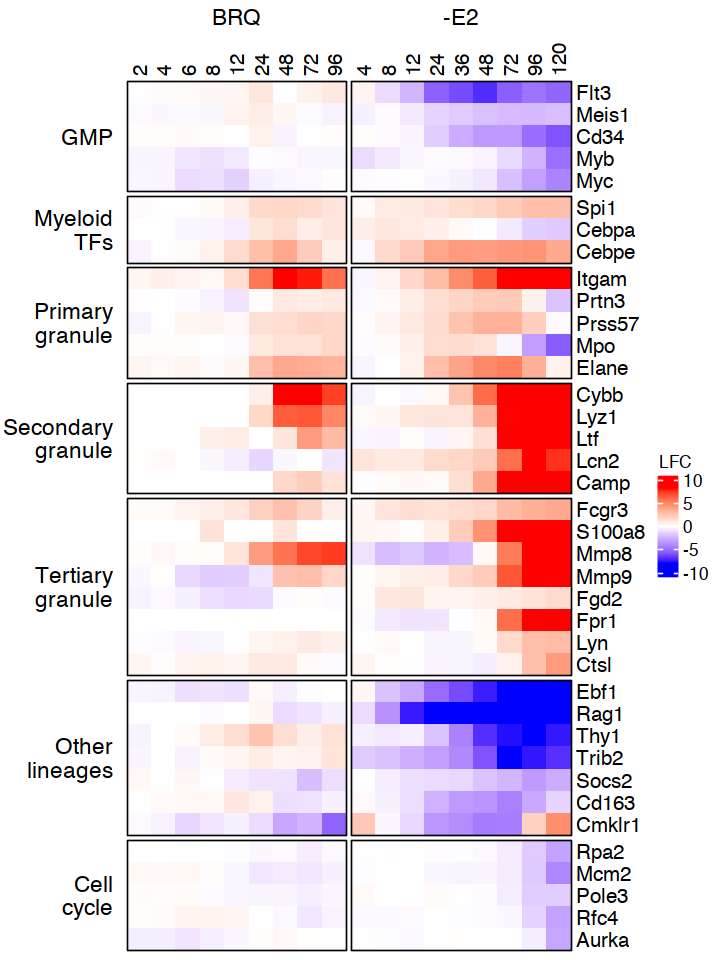

In [21]:
# Heatmap only for key genes 

gmp = c("Flt3", "Meis1", "Cd34", "Myb", "Myc")
tfs = c("Spi1", "Cebpa", "Cebpe")
pri = c("Itgam", "Prtn3", "Prss57", "Mpo", "Elane")
sec = c("Cybb", "Lyz1", "Ltf", "Lcn2", "Camp")
tert = c("Fcgr3", "S100a8", "Mmp8", "Mmp9", "Fgd2", "Fpr1", "Lyn", "Ctsl")
otherlin = c("Ebf1", "Rag1", "Thy1", "Trib2", "Socs2", "Cd163", "Cmklr1")
cc = c("Rpa2", "Mcm2", "Pole3", "Rfc4", "Aurka")

goi = c(gmp, tfs, pri, sec, tert, otherlin, cc)
col_fun = colorRamp2(c(-8, 0, 8), c("blue", "white", "red"))
row_splits = c(rep("GMP", 5), rep("Myeloid\nTFs", 3), rep("Primary\ngranule", 5),
rep("Secondary\ngranule", 5), rep("Tertiary\ngranule", 8), rep("Other\nlineages", 7), rep("Cell\ncycle", 5))
col_splits = factor(c(rep("BRQ", 9), rep("-E2", 9)), levels=c("BRQ", "-E2"))
row_splits = factor(row_splits, levels=c("GMP", "Myeloid\nTFs", "Primary\ngranule",
"Secondary\ngranule", "Tertiary\ngranule", "Other\nlineages", "Cell\ncycle"))

new_df = lfc[goi,c(2:10, 12:20)]
colnames(new_df) = c("2", "4", "6", "8", "12", "24", "48", "72", "96",
"4", "8", "12", "24", "36", "48", "72", "96", "120")
options(repr.plot.width=6, repr.plot.height=8)
h = Heatmap(new_df, cluster_columns=F, cluster_rows=F, col=col_fun,
row_split = row_splits, column_split = col_splits, border=T, row_title_rot = 0,
column_names_side = "top", name="LFC")
draw(h)

# pdf("../output/220424_633_selected_gene_comp.pdf", width=6, height=8)
# draw(h)
# dev.off()


In [25]:
# prepare data
brq_fc = as.data.frame(lfc[,2:10])
e2w_fc = as.data.frame(lfc[,12:19])
colnames(brq_fc) = c(2,4,6,8,12,24,48,72,96)
colnames(e2w_fc) = c(4,8,12,24,36,48,72,96)

# identify up and down genes: at least LFC of 1.5
# brq_up = as.vector(rownames(brq_fc[apply(brq_fc,1,max) > 1.5,]))
# e2w_up = as.vector(rownames(e2w_fc[apply(e2w_fc,1,max) > 1.5,]))
shared_up = intersect(brq_up, e2w_up)
brq_up = brq_up[!(brq_up %in% shared_up)]
e2w_up = e2w_up[!(e2w_up %in% shared_up)]

brq_up = brq_up[order(as.vector(unlist(apply(brq_fc[brq_up,],1,which.max))))]
# brq_up_early = brq_up[apply(brq_fc[brq_up,],1,which.max) < 6]  # 24h
# brq_up_late = brq_up[apply(brq_fc[brq_up,],1,which.max) >= 6]
e2w_up = e2w_up[order(as.vector(unlist(apply(e2w_fc[e2w_up,],1,which.max))))]
# e2w_up_early = e2w_up[apply(e2w_fc[e2w_up,],1,which.max) < 7]  # 36h
# e2w_up_late = e2w_up[apply(e2w_fc[e2w_up,],1,which.max) >= 7]

order1 = as.vector(unlist(apply(brq_fc[shared_up,],1,which.max)))
order2 = as.vector(unlist(apply(e2w_fc[shared_up,],1,which.max)))
shared_order = order(apply(cbind(order1, order2), 1, min))
shared_up = shared_up[shared_order]

up_genes = c(brq_up, e2w_up, shared_up)
row_gaps_up = c(length(brq_up), length(brq_up) + length(e2w_up))
col_gaps = c(dim(brq_fc)[2])

ERROR: Error in xj[i]: invalid subscript type 'list'


In [23]:
# Plot up genes

#png("../figures//brq_upreg_genes.png", units = "in", width=2.5, height=2.5, res=600)
goi_up = match(c("Itgam", "Ltf", "Lcn2", "S100a8", "Mmp9", "Spi1", "Hexim1", "Cebpa",
                 "Cebpe", "Mmp8", "Camp", "Elane", "Il1b", "Oas2", "Rsad2",
                 "Scd1", "Gsn", "Kif3a", "E2f7", "Scd3", "Fasl", "Cdkn1a", 
                 "Lyz1", "Epor", "Ly6e", "Lyn", 
                 "Ifitm2", "Fgd2", "Ctsl", "Clec4d"), up_genes)
ha = rowAnnotation(foo = anno_mark(at = goi_up, labels = up_genes[goi_up], labels_gp=grid::gpar(fontsize = 5)))
rowsplits = c(paste("Up in BRQ\n", as.character(length(brq_up)), " genes", sep=''), 
              paste("Up in Hoxa9 OFF\n", as.character(length(e2w_up)), " genes", sep=''),
              paste("Up in both\n", as.character(length(shared_up)), " genes", sep=''))
rowsplits_up_names = factor(c(rep(rowsplits[1], length(brq_up)), 
                              rep(rowsplits[2], length(e2w_up)),
                              rep(rowsplits[3], length(shared_up))),
                            levels=rowsplits[c(1,3,2)])
col_fun = colorRamp2(c(-3, 0, 3), c("blue", "white", "red"))

# go_splits_up = c(rep("1", length(brq_up_early)), rep("2", length(brq_up_late)), rep("3", length(e2w_up_early)),
#               rep("4", length(e2w_up_late)), rep("5", length(shared_up)))

htu = Heatmap(as.matrix(cbind(brq_fc[up_genes,], e2w_fc[up_genes,])), raster_quality = 5000, col=col_fun,
              cluster_columns=F, border=T, right_annotation=ha,
              column_split = factor(c(rep("BRQ", dim(brq_fc)[2]),
                                      rep("Hoxa9 OFF", dim(e2w_fc)[2])),
                                    levels=c("BRQ", "Hoxa9 OFF")),
              column_names_side = "top", name="LFC", show_row_names=F,
              column_names_gp = grid::gpar(fontsize = 6),
              row_names_gp = grid::gpar(fontsize = 6),
              column_title_gp = grid::gpar(fontsize = 6),
              row_title_gp = grid::gpar(fontsize = 6),
              heatmap_legend_param = list(labels_gp = grid::gpar(fontsize = 6), title_gp = grid::gpar(fontsize=6)))

# htu2 = Heatmap(go_splits_up, col = c("1" = "#99D6FFFF", "2"="#006BB3FF", "3"="#DE8D00FF", 
#                                   "4"="#B36B00FF", "5"="#000000FF"), 
#                show_row_names=F, 
#                name="GO group", show_heatmap_legend=F)
draw(htu, heatmap_legend_side = "left", 
     row_split = rowsplits_up_names, cluster_rows=F)
# dev.off()
# dev.off()

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'table' in selecting a method for function 'match': object 'up_genes' not found


In [23]:
# get down genes

# brq_down = as.vector(rownames(brq_fc[apply(brq_fc,1,min) < -1.5,]))
# e2w_down = as.vector(rownames(e2w_fc[apply(e2w_fc,1,min) < -1.5,]))
shared_down = intersect(brq_down, e2w_down)
brq_down = brq_down[!(brq_down %in% shared_down)]
e2w_down = e2w_down[!(e2w_down %in% shared_down)]

brq_down = brq_down[order(as.vector(unlist(apply(brq_fc[brq_down,],1,which.min))))]
# brq_down_early = brq_down[apply(brq_fc[brq_down,],1,which.min) < 6]  # 24h
# brq_down_late = brq_down[apply(brq_fc[brq_down,],1,which.min) >= 6]
e2w_down = e2w_down[order(as.vector(unlist(apply(e2w_fc[e2w_down,],1,which.min))))]
# e2w_down_early = e2w_down[apply(e2w_fc[e2w_down,],1,which.min) < 7]  # 36h
# e2w_down_late = e2w_down[apply(e2w_fc[e2w_down,],1,which.min) >= 7]
shared_down = shared_down[order(as.vector(unlist(apply(brq_fc[shared_down,],1,which.min))))]
down_genes = c(brq_down, e2w_down, shared_down)
row_gaps_down = c(length(brq_down), length(brq_down) + length(e2w_down))
col_gaps = c(dim(brq_fc)[2])

In [22]:
# plot down genes

png("../figures//brq_downreg_genes.png", units = "in", width=2, height=2.5, res=600)
goi_down = match(c("Myb", "Hoxa9", "Ebf1", "Thy1", "Cd34", "Meis1",
                   "Trib2", "Sox4", "Flt3", "Pole3", "Rfc4", "Mcm2", "Rpa2",
                   "Aurka","Fos", "Myc", "Cd163", "Cd19", "Socs2", "Sox2"), down_genes)
had = rowAnnotation(foo = anno_mark(at = goi_down, labels = down_genes[goi_down],
                   labels_gp=grid::gpar(fontsize = 6)))
rowsplits_down = c(paste("Down in BRQ\n", as.character(length(brq_down)), " genes", sep=''), 
                   paste("Down in Hoxa9 OFF\n", as.character(length(e2w_down)), " genes", sep=''),
                   paste("Down in both\n", as.character(length(shared_down)), " genes", sep=''))
rowsplits_down_names = factor(c(rep(rowsplits_down[1], length(brq_down)), 
                                rep(rowsplits_down[2], length(e2w_down)),
                                rep(rowsplits_down[3], length(shared_down))),
                                levels=rowsplits_down[c(1,3,2)])
# go_splits = c(rep("1", length(brq_down_early)), rep("2", length(brq_down_late)), rep("3", length(e2w_down_early)),
#               rep("4", length(e2w_down_late)), rep("5", length(shared_down)))


col_fun = colorRamp2(c(-3, 0, 3), c("blue", "white", "red"))
htd = Heatmap(as.matrix(cbind(brq_fc[down_genes,], e2w_fc[down_genes,])), col = col_fun,
              cluster_columns=F, border=T, right_annotation=had,
              column_split = factor(c(rep("BRQ", dim(brq_fc)[2]),
                                      rep("Hoxa9 OFF", dim(e2w_fc)[2])),
                                    levels=c("BRQ", "Hoxa9 OFF")),
              column_names_side = "top", name="LFC", show_row_names=F,
              column_names_gp = grid::gpar(fontsize = 6),
              row_names_gp = grid::gpar(fontsize = 6),
              column_title_gp = grid::gpar(fontsize = 6),
              row_title_gp = grid::gpar(fontsize = 6))
# htd2 = Heatmap(go_splits, col = c("1" = "#99D6FFFF", "2"="#006BB3FF", "3"="#DE8D00FF", 
#                                   "4"="#B36B00FF", "5"="#000000FF"), 
#                show_row_names=F, right_annotation=had,
#                name="GO group", show_heatmap_legend=F)
draw(htd, cluster_rows=F, show_heatmap_legend = FALSE,
     row_split = rowsplits_down_names)
dev.off()
dev.off()

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



pdf 
  2

quartz_off_screen 
                3

## Analysis of CAF-1 OFF genes

In [ ]:
# function multijoin() {
#     out=$1
#     shift 1
#     cat $1 | awk '{print $1}' > $out
#     for f in $*; do join $out $f > tmp; mv tmp $out; done
# }

# multijoin GSE158227_RAW_all.txt *.txt

In [55]:
caf1_data = read.table("../data/GSE158227_RAW/GSE158227_RAW_all.txt", row.names=1)
colnames(caf1_data) = c("t0_r1", "t0_r2", "caf1off_r1", "caf1off_r2", "iptg_r1", "iptg_r2", "hoxa9off_r1", "hoxa9off_r2")
head(caf1_data)

,t0_r1,t0_r2,caf1off_r1,caf1off_r2,iptg_r1,iptg_r2,hoxa9off_r1,hoxa9off_r2
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
0610005C13Rik,16,25,18,16,5,10,7,15
0610007C21Rik,779,676,601,766,429,442,1011,1173
0610007L01Rik,4685,5081,3218,3133,3097,3344,4721,4790
0610007N19Rik,0,0,0,0,0,0,0,0
0610007P08Rik,1111,1139,1049,1103,747,773,527,591
0610007P14Rik,1624,1654,1160,1022,1077,1038,1084,1062


In [56]:
# limma-voom normalization

d0 <- DGEList(caf1_data)
d0 <- calcNormFactors(d0)
cutoff <- 3
drop <- which(apply(cpm(d0), 1, max) < cutoff)
d <- d0[-drop,] 
dim(d) # number of genes left

[1] 10340     8

In [62]:
# get DEGs
conds = c("t0", "t0", "caf1off", "caf1off", "iptg", "iptg", "hoxa9off", "hoxa9off")
mm <- model.matrix(~0 + conds)
y <- voom(d, mm, plot = F)
fit2 <- lmFit(y, mm)
head(coef(fit2))

,condscaf1off,condshoxa9off,condsiptg,condst0
0610007C21Rik,4.074490,4.779527,3.792559,3.938225
0610007L01Rik,6.299911,6.904921,6.680572,6.688354
0610007P08Rik,4.738745,3.815724,4.596321,4.571898
0610007P14Rik,4.756201,4.756782,5.072257,5.114689
0610007P22Rik,3.172855,2.702107,3.520524,3.353890
0610009B22Rik,3.506163,3.588437,3.274780,3.225233


In [65]:
# get list of differentially expressed genes for each timepoint 
caf1off = process_res(makeContrasts("condscaf1off - condsiptg", levels = colnames(coef(fit2))), fit2)
hoxa9off = process_res(makeContrasts("condshoxa9off - condst0", levels = colnames(coef(fit2))), fit2)
caf1off_vs_hoxa9off = process_res(makeContrasts("condscaf1off - condshoxa9off", levels = colnames(coef(fit2))), fit2)
iptg_vs_t0 = process_res(makeContrasts("condsiptg - condst0", levels = colnames(coef(fit2))), fit2)

In [66]:
# iptg and t0 should be very similar
dim(subset(iptg_vs_t0, logFC > 1 & adj.P.Val < 0.05))
dim(subset(iptg_vs_t0, logFC < -1 & adj.P.Val < 0.05))

[1] 0 6

[1] 0 6

In [67]:
# pretty good concordance between Cheloufi Hoxa9 OFF and Sykes -E2 for upregulated genes
a = subset(hoxa9off, logFC > 1 & adj.P.Val < 0.05)  # 1845
b = subset(e2w_degs[["48"]], logFC > 1 & adj.P.Val < 0.05)  # 1327
length(intersect(rownames(a), rownames(b))) # 789

a = subset(hoxa9off, logFC < -1 & adj.P.Val < 0.05)  # 1405
b = subset(e2w_degs[["48"]], logFC < -1 & adj.P.Val < 0.05)  # 951
length(intersect(rownames(a), rownames(b))) # 365

[1] 789

[1] 365

In [68]:
# pretty good concordance between Cheloufi Caf-1 OFF and Sykes BRQ for up genes 
a = subset(caf1off, logFC > 1 & adj.P.Val < 0.05)  # 430
b = subset(brq_degs[["48"]], logFC > 1 & adj.P.Val < 0.05)  # 1926
length(intersect(rownames(a), rownames(b))) # 239

a = subset(caf1off, logFC < -1 & adj.P.Val < 0.05)  # 74
b = subset(brq_degs[["48"]], logFC < -1 & adj.P.Val < 0.05)  # 1568
length(intersect(rownames(a), rownames(b))) # 25

[1] 239

[1] 25

In [69]:
# BRQ 48h vs -E2 48h
formula = paste("condsBRQ_48h - conds633_E2w_48h", sep='')
brq_vs_e2 = process_res(makeContrasts(formula, levels = colnames(coef(fit))), fit)

In [91]:
# Compare genes that go up in BRQ vs E2 with genes that go up in CAF1off vs Hoxa9off 
a = subset(brq_vs_e2, logFC > 1 & adj.P.Val < 0.05)  # 1760
b = subset(caf1off_vs_hoxa9off, logFC > 1 & adj.P.Val < 0.05)  # 1203
up_in_both = intersect(rownames(a), rownames(b))
length(up_in_both) # 372


[1] 372

In [97]:
fisher.test(data.frame(c(1760, 12983), c(372, 1203)))


	Fisher's Exact Test for Count Data

data:  data.frame(c(1760, 12983), c(372, 1203))
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3858156 0.4989651
sample estimates:
odds ratio 
 0.4384182 


In [110]:
genes_in_common = intersect(rownames(brq_vs_e2), rownames(caf1off_vs_hoxa9off))
combined = as.data.frame(cbind(brq_vs_e2[genes_in_common, "logFC"], caf1off_vs_hoxa9off[genes_in_common, "logFC"],
caf1off[genes_in_common, "logFC"], hoxa9off[genes_in_common, "logFC"],
brq_degs[["48"]][genes_in_common, "logFC"], e2w_degs[["48"]][genes_in_common, "logFC"]))
rownames(combined) = genes_in_common
colnames(combined) = c("brq_vs_e2", "caf1off_vs_hoxa9off", "caf1off", "hoxa9off", "brq48", "e2wd48")
combined$label = rownames(combined)
head(combined)

,brq_vs_e2,caf1off_vs_hoxa9off,caf1off,hoxa9off,brq48,e2wd48,label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Sdc1,7.209494,3.3541956,-0.90894502,-4.2690805,0.87276995,-5.701308,Sdc1
Ccr2,5.916313,0.2817301,-0.59820867,-0.9304044,0.77555672,-5.491986,Ccr2
Flt3,6.901536,5.7698789,-0.17695600,-5.9694653,-0.07720818,-7.203856,Flt3
Ccdc80,3.281026,1.8204762,3.24019316,1.3602755,2.93024424,-0.169550,Ccdc80
Cd34,2.498919,2.8843470,0.08663467,-2.8556247,-0.45091677,-3.539006,Cd34
Gm16897,2.769885,2.4027492,-0.22708983,-2.4532150,-0.37385501,-3.475122,Gm16897


`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

Warning message:
"ggrepel: 277 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


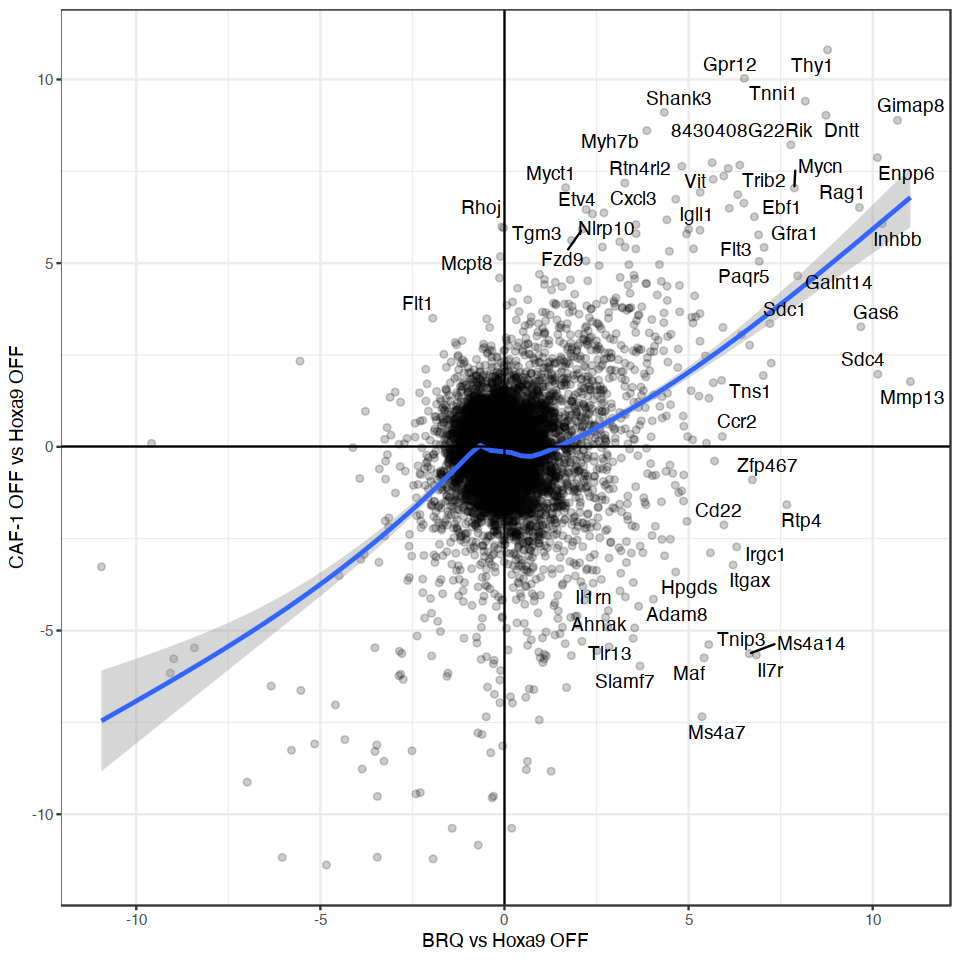

In [111]:
# this plot does not distinguish between genes that go down only in -E2, and genes that also go up with BRQ/CAF-1 off
options(repr.plot.width=8, repr.plot.height=8)
ggplot(combined, aes(x=brq_vs_e2, y=caf1off_vs_hoxa9off)) + geom_point(alpha=0.2) + 
geom_smooth() + geom_hline(yintercept=0) + geom_vline(xintercept=0) +
geom_text_repel(data=subset(combined, brq_vs_e2 > 3 | caf1off_vs_hoxa9off > 3), aes(label=label)) +
theme_bw() + xlab("BRQ vs Hoxa9 OFF") + ylab("CAF-1 OFF vs Hoxa9 OFF")

In [116]:
dim(subset(combined[up_in_both,], brq48 > 1))
dim(subset(combined[up_in_both,], caf1off > 1))
dim(subset(combined[up_in_both,], caf1off > 1 & brq48 > 1))

[1] 92  7

[1] 128   7

[1] 66  7

In [119]:
fisher.test(data.frame(c(92, 372), c(66, 128)))


	Fisher's Exact Test for Count Data

data:  data.frame(c(92, 372), c(66, 128))
p-value = 0.0001952
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3246956 0.7115340
sample estimates:
odds ratio 
 0.4802129 


Warning message:
"The input is a data frame, convert it to a matrix."


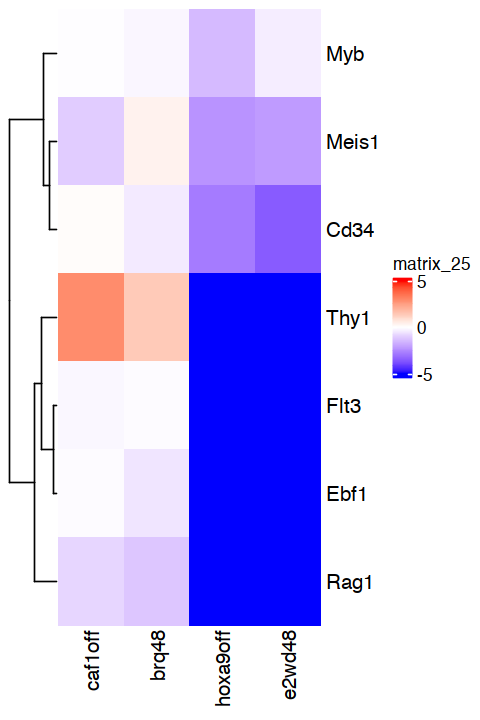

In [136]:
options(repr.plot.width=4, repr.plot.height=6)
z = combined[, c(3, 5, 4, 6)]
col_fun = colorRamp2(c(-5, 0, 5), c("blue", "white", "red"))
Heatmap(z[c("Cd34", "Flt3", "Rag1", "Meis1", "Ebf1", "Myb", "Thy1"),],
cluster_columns=F, col=col_fun)

Warning message:
"The input is a data frame, convert it to a matrix."


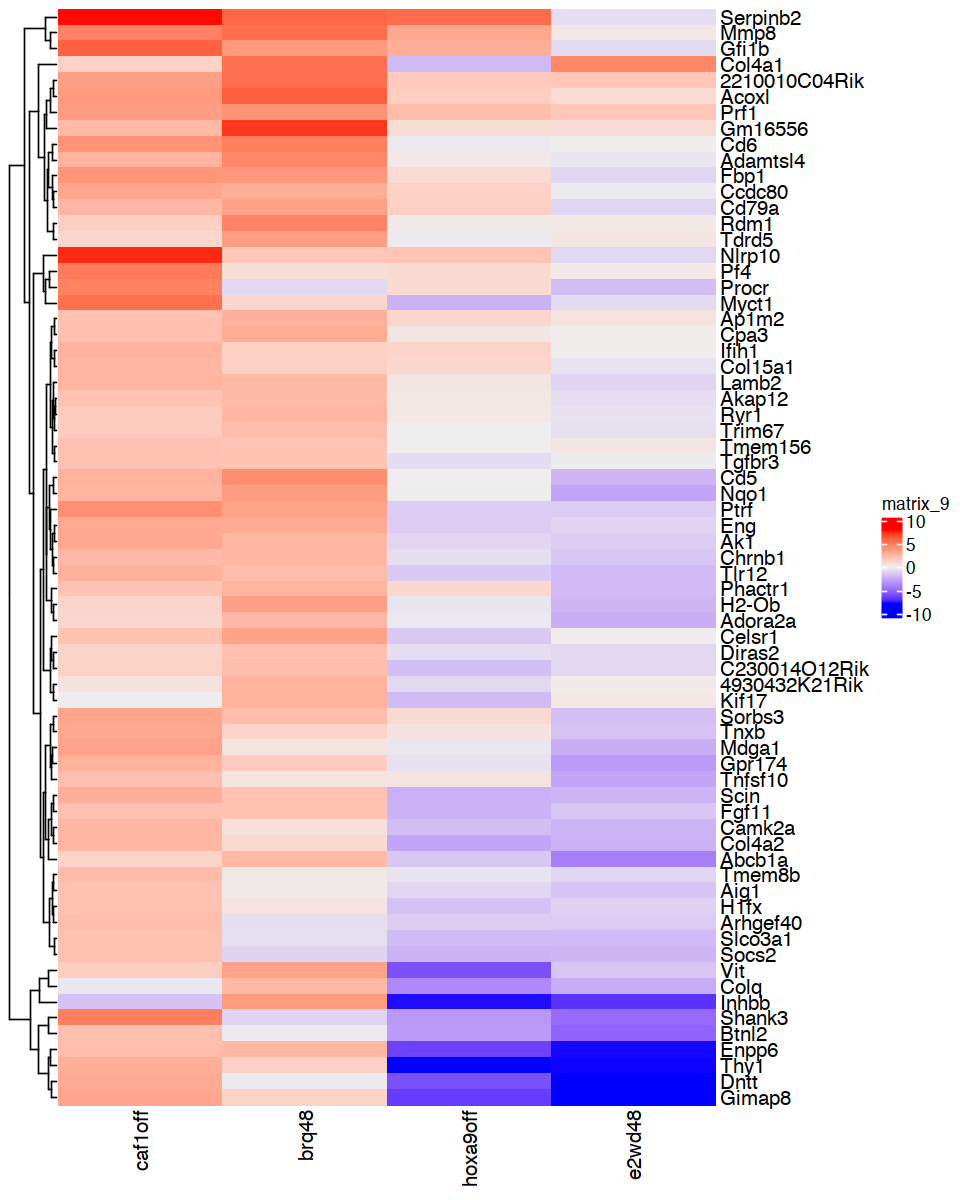

In [102]:
options(repr.plot.width=8, repr.plot.height=10)
z = combined[up_in_both, c(3, 5, 4, 6)]
z = z[order(z$caf1off),]
z = subset(z, caf1off > 2 | brq48 > 2)
Heatmap(z, cluster_columns=F)

[1] 996

[1] 223

[1] 65

,brq_vs_t0,caf1off_vs_iptg,label
,<dbl>,<dbl>,<chr>
Tdrd5,3.606092,1.0956056,Tdrd5
Cd200r4,3.773528,1.4603427,Cd200r4
Ccdc80,2.930244,3.2401932,Ccdc80
Cd33,2.500050,0.8243716,Cd33
Cd93,2.258894,-0.2531165,Cd93
Itgb7,4.418789,1.0035649,Itgb7


Warning message:
"Removed 359 rows containing missing values (geom_point)."
Warning message:
"Removed 359 rows containing missing values (geom_text_repel)."
Warning message:
"ggrepel: 746 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


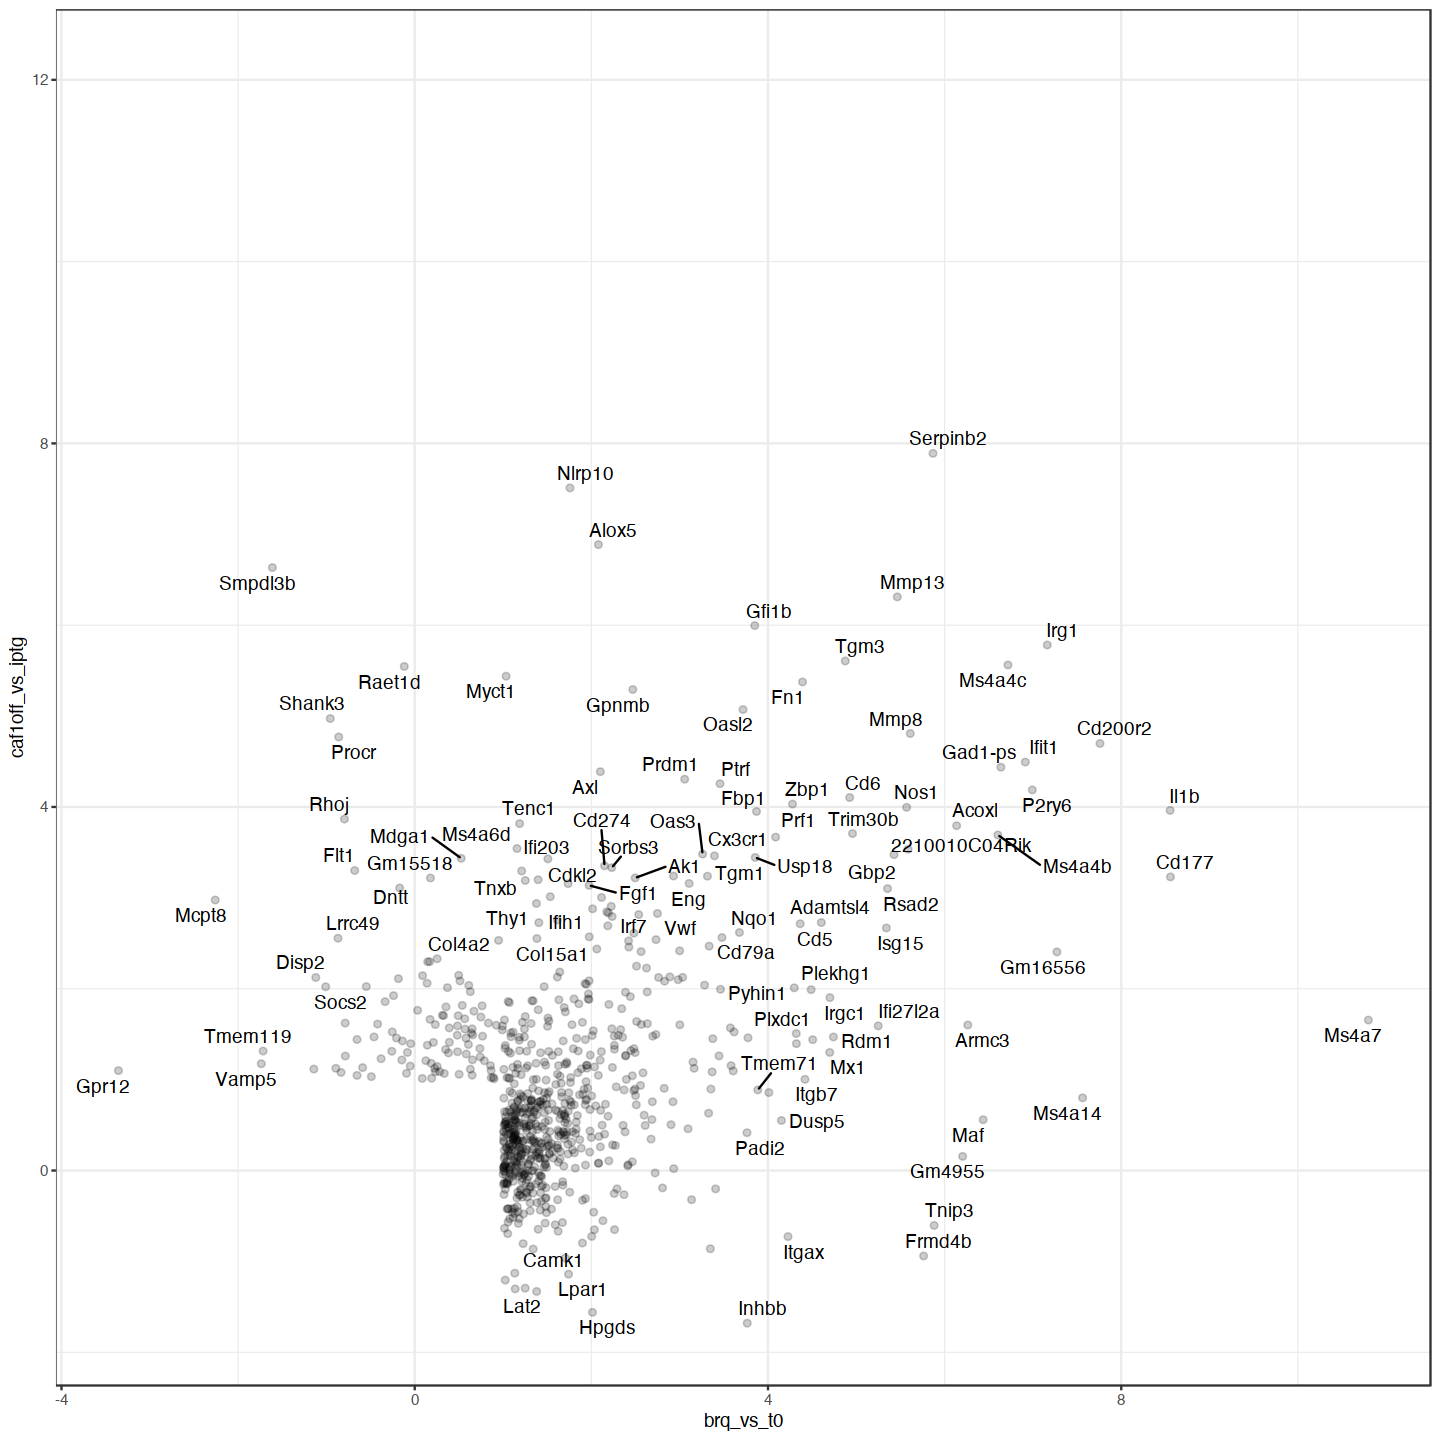

In [103]:
# look at genes that are specifically up in BRQ or CAF-1off
brq_up_genes = setdiff(rownames(subset(brq_degs[["48"]], logFC > 1 & adj.P.Val < 0.05)), 
                       rownames(subset(e2w_degs[["48"]], logFC > 1 & adj.P.Val < 0.05)))

caf1_up_genes = setdiff(rownames(subset(caf1off, logFC > 1 & adj.P.Val < 0.05)), 
                        rownames(subset(hoxa9off, logFC > 1 & adj.P.Val < 0.05)))

length(brq_up_genes)  # 996
length(caf1_up_genes)  # 223
length(intersect(brq_up_genes, caf1_up_genes))  # 65

g = union(brq_up_genes, caf1_up_genes)
combined = as.data.frame(cbind(brq_degs[["48"]][g, "logFC"], 
caf1off[g, "logFC"]))
rownames(combined) = g
colnames(combined) = c("brq_vs_t0", "caf1off_vs_iptg")
combined$label = rownames(combined)
head(combined)

# genes that are specifically up in either BRQ or CAF-1 off
options(repr.plot.width=12, repr.plot.height=12)
ggplot(combined, aes(x=brq_vs_t0, y=caf1off_vs_iptg, label=label)) + geom_point(alpha=0.2) +
geom_text_repel() +
theme_bw()

In [92]:
intersect(brq_up_genes, caf1_up_genes)

[1] "Ccdc80"        "Cpa3"          "Fbp1"          "Ryr1"         
 [5] "Tinagl1"       "Tmem156"       "St8sia4"       "Lamb2"        
 [9] "Dync2li1"      "Tgfbr3"        "Zfp658"        "Il3ra"        
[13] "Acoxl"         "H2-T22"        "Pmaip1"        "Chrnb1"       
[17] "Adamtsl4"      "Gfi1b"         "Serinc5"       "Gp9"          
[21] "Cuedc1"        "Btnl9"         "Ak1"           "Phactr1"      
[25] "Rnf157"        "H2-T10"        "Itgal"         "Eng"          
[29] "Tlr12"         "Myo15b"        "Akap12"        "Acacb"        
[33] "Thy1"          "Cd5"           "Nkg7"          "Hgf"          
[37] "Enpp6"         "Rhd"           "Cd6"           "Scin"         
[41] "Nqo1"          "Nlrp10"        "Gm16556"       "Gpr174"       
[45] "Fndc3b"        "C230014O12Rik" "Slc24a3"       "Exoc3l2"      
[49] "Ift122"        "Hlcs"          "Celsr1"        "Vit"          
[53] "Il12rb1"       "St3gal6"       "Col15a1"       "Parvb"        
[57] "Csgalnact1"    "Gimap8"        "Sorbs3"        "Six4"         
[61] "Ptrf"          "Gnat2"         "Tnfaip8l1"     "Gm15581"      
[65] "Myct1"

## Analysis of Hoxa9 targets -- from GREAT and CUT&RUN


In [24]:
hoxa9_genes = read.table("../data/20220207-public-4.0.4-fH4tgu-mm10-all-gene.txt", sep='\t')
hoxa9_genes = hoxa9_genes[,1]
hoxa9_genes = hoxa9_genes[which(hoxa9_genes %in% rownames(brq_degs[['2']]))]
length(hoxa9_genes)

[1] 627

In [25]:
print(length(brq_up))
print(length(shared_up))
print(length(e2w_up))
print(length(brq_down))
print(length(shared_down))
print(length(e2w_down))

[1] 925
[1] 1989
[1] 1571
[1] 1254
[1] 1462
[1] 2049


In [26]:
# Fisher's exact test, comparison with 627 12983 
fisher_test = function(x) {
    nintersect = length(intersect(hoxa9_genes, x))
    ngenes = dim(brq_degs[['2']])[1]
    fisher.test(matrix(c(nintersect, length(x),
    length(hoxa9_genes), ngenes), nrow = 2))
}

fisher_test(brq_up)  # 1.5e-6, OR 1.87, 84 931 
fisher_test(shared_up)  # 9e-4, OR 1.4, 135/1999
fisher_test(e2w_up)  # 0.803, OR 1.03, 78/1563
fisher_test(brq_down)  # 0.025, OR 0.706, 46/1350
fisher_test(shared_down) # 0.14, OR 1.19, 85/1483
fisher_test(e2w_down) # 1.0e-9, OR 1.78, 174/2038


	Fisher's Exact Test for Count Data

data:  matrix(c(nintersect, length(x), length(hoxa9_genes), ngenes), nrow = 2)
p-value = 9.734e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.464835 2.389478
sample estimates:
odds ratio 
  1.880335 



	Fisher's Exact Test for Count Data

data:  matrix(c(nintersect, length(x), length(hoxa9_genes), ngenes), nrow = 2)
p-value = 0.001073
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.141975 1.694308
sample estimates:
odds ratio 
  1.394975 



	Fisher's Exact Test for Count Data

data:  matrix(c(nintersect, length(x), length(hoxa9_genes), ngenes), nrow = 2)
p-value = 0.71
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8085555 1.3259439
sample estimates:
odds ratio 
  1.041263 



	Fisher's Exact Test for Count Data

data:  matrix(c(nintersect, length(x), length(hoxa9_genes), ngenes), nrow = 2)
p-value = 0.007288
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.4512208 0.8956922
sample estimates:
odds ratio 
 0.6439998 



	Fisher's Exact Test for Count Data

data:  matrix(c(nintersect, length(x), length(hoxa9_genes), ngenes), nrow = 2)
p-value = 0.182
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.9176011 1.4901915
sample estimates:
odds ratio 
  1.175517 



	Fisher's Exact Test for Count Data

data:  matrix(c(nintersect, length(x), length(hoxa9_genes), ngenes), nrow = 2)
p-value = 8.274e-10
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.477301 2.108413
sample estimates:
odds ratio 
  1.768416 


In [26]:
library(stats)
ngenes = dim(brq_degs[['2']])[1]
fisher.test(matrix(c(174, 2038, 627, ngenes), nrow = 2))


	Fisher's Exact Test for Count Data

data:  matrix(c(174, 2038, 627, ngenes), nrow = 2)
p-value = 1.015e-09
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.476285 2.108506
sample estimates:
odds ratio 
  1.767801 


In [27]:
# genes that are bound by Hoxa9, and also downregulated when E2 is withdrawn 
intersect(hoxa9_genes, e2w_down)

[1] "8430408G22Rik" "A830080D01Rik" "Abca1"         "Abcb1a"       
  [5] "Abcb1b"        "Ablim1"        "Adrb2"         "Ahi1"         
  [9] "Ahr"           "Aldh1b1"       "Angpt1"        "Antxr2"       
 [13] "Anxa2"         "Apbb2"         "Arhgap35"      "Arhgap6"      
 [17] "Armcx4"        "Asph"          "Atp10a"        "B4galt4"      
 [21] "BC048403"      "Bcl2l14"       "Bend4"         "Btla"         
 [25] "Calcrl"        "Camk1d"        "Ccl2"          "Ccl9"         
 [29] "Cd180"         "Cd300e"        "Cd33"          "Cd34"         
 [33] "Cebpa"         "Cers6"         "Chdh"          "Chst1"        
 [37] "Clec12a"       "Clic5"         "Coro2a"        "Cpa3"         
 [41] "Cpt1a"         "Cuedc1"        "Dapp1"         "Dopey2"       
 [45] "Drosha"        "Eepd1"         "Enpp6"         "Epha4"        
 [49] "Ern1"          "Etaa1"         "Fam210a"       "Fam46a"       
 [53] "Fam49a"        "Fam84b"        "Fancc"         "Fbp1"         
 [57] "Flt3"          "Frmpd1"        "Fut8"          "Fxn"          
 [61] "Fyb"           "Gas6"          "Gata2"         "Gca"          
 [65] "Gch1"          "Gcnt4"         "Gfi1"          "Gfi1b"        
 [69] "Gfra1"         "Gimap1"        "Gimap6"        "Gmpr"         
 [73] "Gsta4"         "Gtf3c5"        "Gtf3c6"        "Heg1"         
 [77] "Hgf"           "Hibadh"        "Hlf"           "Hs2st1"       
 [81] "Icam2"         "Ice2"          "Ick"           "Ikzf2"        
 [85] "Il10rb"        "Il17ra"        "Il7"           "Il7r"         
 [89] "Irf2"          "Irs2"          "Jade2"         "Kansl1l"      
 [93] "Katnal1"       "Kcnh7"         "Kit"           "Klrb1f"       
 [97] "Lhfpl2"        "Lpar1"         "Map4k4"        "Meis1"        
[101] "Mex3b"         "Mfhas1"        "Ms4a6d"        "Msi2"         
[105] "Muc13"         "Mycn"          "Nrg1"          "Nrgn"         
[109] "Nsmaf"         "Nudt5"         "Nup107"        "Olfm1"        
[113] "P2ry1"         "Papss2"        "Paqr5"         "Pbx3"         
[117] "Pde4b"         "Pde7b"         "Pdhx"          "Phtf2"        
[121] "Pip4k2a"       "Pla2g4a"       "Plscr4"        "Ppfia4"       
[125] "Ppp1r14c"      "Psd3"          "Ptger3"        "Ptger4"       
[129] "Rab38"         "Rag2"          "Ralgps2"       "Raph1"        
[133] "Rbpms"         "Reps1"         "Rgs1"          "Rttn"         
[137] "Sall3"         "Samsn1"        "Satb1"         "Sdc1"         
[141] "Sh3d19"        "Shb"           "Siae"          "Slc44a1"      
[145] "Slc9a9"        "Snapc3"        "Snd1"          "Socs5"        
[149] "Sod1"          "Spef2"         "Srl"           "Ssfa2"        
[153] "St3gal1"       "St6gal1"       "St8sia4"       "Stmn1"        
[157] "Stxbp4"        "Tet1"          "Tgfbr2"        "Tgfbr3"       
[161] "Tgtp1"         "Tgtp2"         "Trib2"         "Trp53bp2"     
[165] "Ttc39b"        "Tuba8"         "Usp6nl"        "Ywhaq"        
[169] "Zfp1"          "Zfp326"        "Zfp422"        "Zfp608"       
[173] "Zfp637"        "Zfp658"        "Zfp703"

## Num of DEGs

In [167]:
# get BRQ up and down
brq_chg = list()

for (tp in names(brq_degs)) {
    res = brq_degs[[tp]]
    up = length(rownames(res[res$logFC > 1 & res$adj.P.Val < 0.05,]))
    down = length(rownames(res[res$logFC < -1 & res$adj.P.Val < 0.05,]))
    brq_chg[[tp]] = c(up, down)
}

# get E2w up and down
e2w_chg = list()

for (tp in names(e2w_degs)) {
    res = e2w_degs[[tp]]
    up = length(rownames(res[res$logFC > 1 & res$adj.P.Val < 0.05,]))
    down = length(rownames(res[res$logFC < -1 & res$adj.P.Val < 0.05,]))
    e2w_chg[[tp]] = c(up, down)
}

In [168]:
brq_num_chg = as.data.frame(t(matrix(unlist(brq_chg),nrow=2)))
brq_num_chg$tp = c(2,4,6,8,12,24,48,72,96)
brq_num_chg$tx = "BRQ"

e2w_num_chg = as.data.frame(t(matrix(unlist(e2w_chg),nrow=2)))
e2w_num_chg$tp = c(4,8,12,24,36,48,72,96)
e2w_num_chg$tx = "-E2"

num_chg = rbind(brq_num_chg, e2w_num_chg)
colnames(num_chg) = c("up", "down", "tp", "tx")
num_chg$down = -num_chg$down

num_chg_up = num_chg[,c(1,3,4)]
num_chg_up$direction = "up"
colnames(num_chg_up) = c("num_genes", "tp", "tx", "direction")
num_chg_down = num_chg[,c(2,3,4)]
num_chg_down$direction = "down"
colnames(num_chg_down) = c("num_genes", "tp", "tx", "direction")

num_chg = rbind(num_chg_up, num_chg_down)
num_chg$tx <- factor(num_chg$tx, levels = c("BRQ", "-E2"))

num_chg

num_genes,tp,tx,direction
<int>,<dbl>,<fct>,<chr>
0,2,BRQ,up
87,4,BRQ,up
355,6,BRQ,up
748,8,BRQ,up
1252,12,BRQ,up
1822,24,BRQ,up
1930,48,BRQ,up
1738,72,BRQ,up
1310,96,BRQ,up


In [169]:
pdf("../figures/num_dysreg_genes.pdf", width=1.33, height=2)
ggplot(data=num_chg, aes(x=tp, y=num_genes, color=tx, group=interaction(tx, direction))) + 
geom_line(size=0.25) + geom_point(size=0.4) + theme_bw() + 
geom_hline(yintercept=c(0),linetype="dashed", size=0.25) +
ggtitle("Number of DEGs") +
labs(x="Hours") + labs(y="") + 
theme(panel.border = element_blank(), 
      legend.position = "none",
      panel.grid.minor = element_blank(),
      panel.grid.major = element_blank(),
      axis.line = element_line(colour = "black", size=0.25),
      text = element_text(size = 6),
      axis.text.y=element_blank(),  # -2000, 0, and 2000
      plot.title = element_text(size=8))
dev.off()
dev.off()

pdf 
  2

pdf 
  3